In [43]:
import matplotlib.pyplot as plt
import importlib, os
import numpy as np, networkx as nx, gudhi as gd
from IPython.display import display

import gudhi_persistence as gp
import utilsA1 as utils
import test_WTM as wtm

PATH = os.getcwd()
output_file = "gudhi_persistence"
print(PATH)


C:\Users\sranasin\Desktop\NetworkModels\Project1\A1


In [51]:
importlib.reload(wtm)
importlib.reload(utils)
importlib.reload(gp)

params_temp_list = {'num_nodes': 50, 'num_neighbor_nodes': 1,
                    'total_random_edges': 3, 'distance_threshold': 2, 'weighted': False,
                    'ngeo_placement': 'ngeo_per_node', 'n_seeds': 2, 'node_active_threshold': 0.01,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
                    'seeding_method': 'cluster_seeding'}

params_temp_list['threshold_sum']= sum(range(params_temp_list['num_nodes'])) - 1

G, seed_nodes = wtm.simulate_contagion_map(params=params_temp_list)
graph, snapshots, activation_times, results = wtm.simulate_contagion_realization(graph = G, init_seeds = seed_nodes, params = params_temp_list,
max_steps = 100, sim_id = 1, realization_id = 1)

utils.visualize_step_animation_new(G=graph, snapshots=snapshots,
                         output_file= os.path.join(PATH, 'Outputs', f"{output_file}.html"))

In [52]:
results

[{'simulation_id': 1,
  'realization_id': 1,
  'num_nodes': 50,
  'time': 0,
  'state': 0,
  'state_abnormal_sum': 1224,
  'num_active_nodes': 2,
  'active_nodes': array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,  0., nan,
         nan, nan,  0., nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]),
  'node_active_threshold': 0.01,
  'H0': 2,
  'H1': 0,
  'H2': 0,
  'total_geo_edges': 50,
  'total_non_geo_edges': 75,
  'num_seeds': 2,
  'seed_nodes': (np.int64(24), np.int64(28)),
  'seed_cluster_distance': 10,
  'weighted': False,
  'average_weight_per_edge': np.float64(0.0),
  'skew_power': 3,
  'upper_weight_limit': 5,
  'distance_threshold': 2},
 {'simulation_id': 1,
  'realization_id': 1,
  'num_nodes': 50,
  'time': 1,
  'state': 0,
  'state_abnormal_sum': 1224,
  'num_active_nodes': 11,
  'active_nodes': array([nan, nan, nan, nan, na

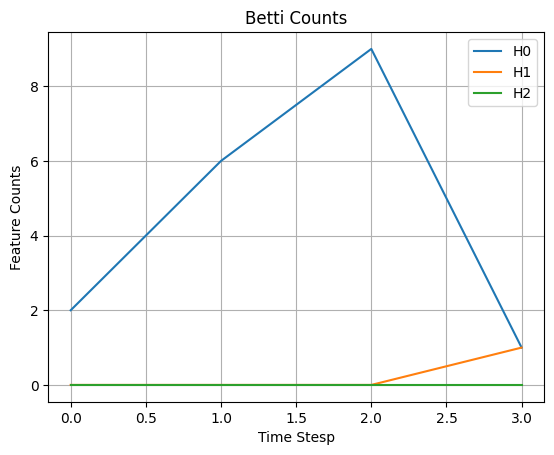

In [53]:
importlib.reload(gp)

betti_numbers, simplex_intervals = gp.compute_persistence(graph=graph, activation_times=activation_times, max_dim=2)
gp.betti_nums_over_time(betti_over_time=betti_numbers)

In [40]:
betti_numbers

{0: {0: 2, 1: 0, 2: 0},
 1: {0: 2, 1: 0, 2: 0},
 2: {0: 1, 1: 0, 2: 0},
 3: {0: 1, 1: 1, 2: 0}}

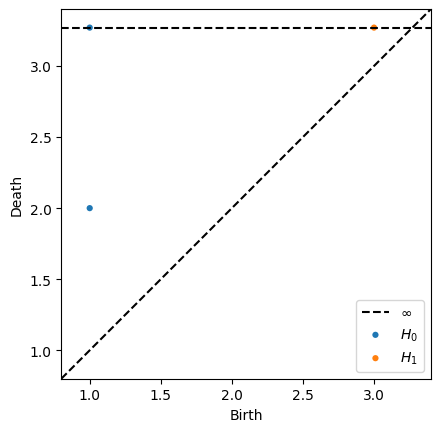

In [41]:
gp.persim_diagram(simplex_intervals=simplex_intervals)

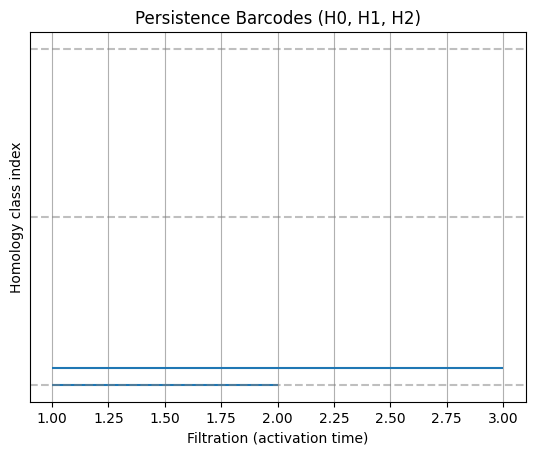

In [42]:
gp.plot_persistence_barcodes(simplex_intervals, activation_times, max_dim=2)